# Tesla Deliveries ML Pipeline (2015–2025)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1. Loading the Data

loading the dataset and doing a basic check — shape, types, missing values

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print('Shape:', df.shape)

Shape: (2640, 12)


In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


## 2. EDA — Exploratory Data Analysis

### a. Univariate Analysis

looking at the distribution of each numerical column individually using histograms

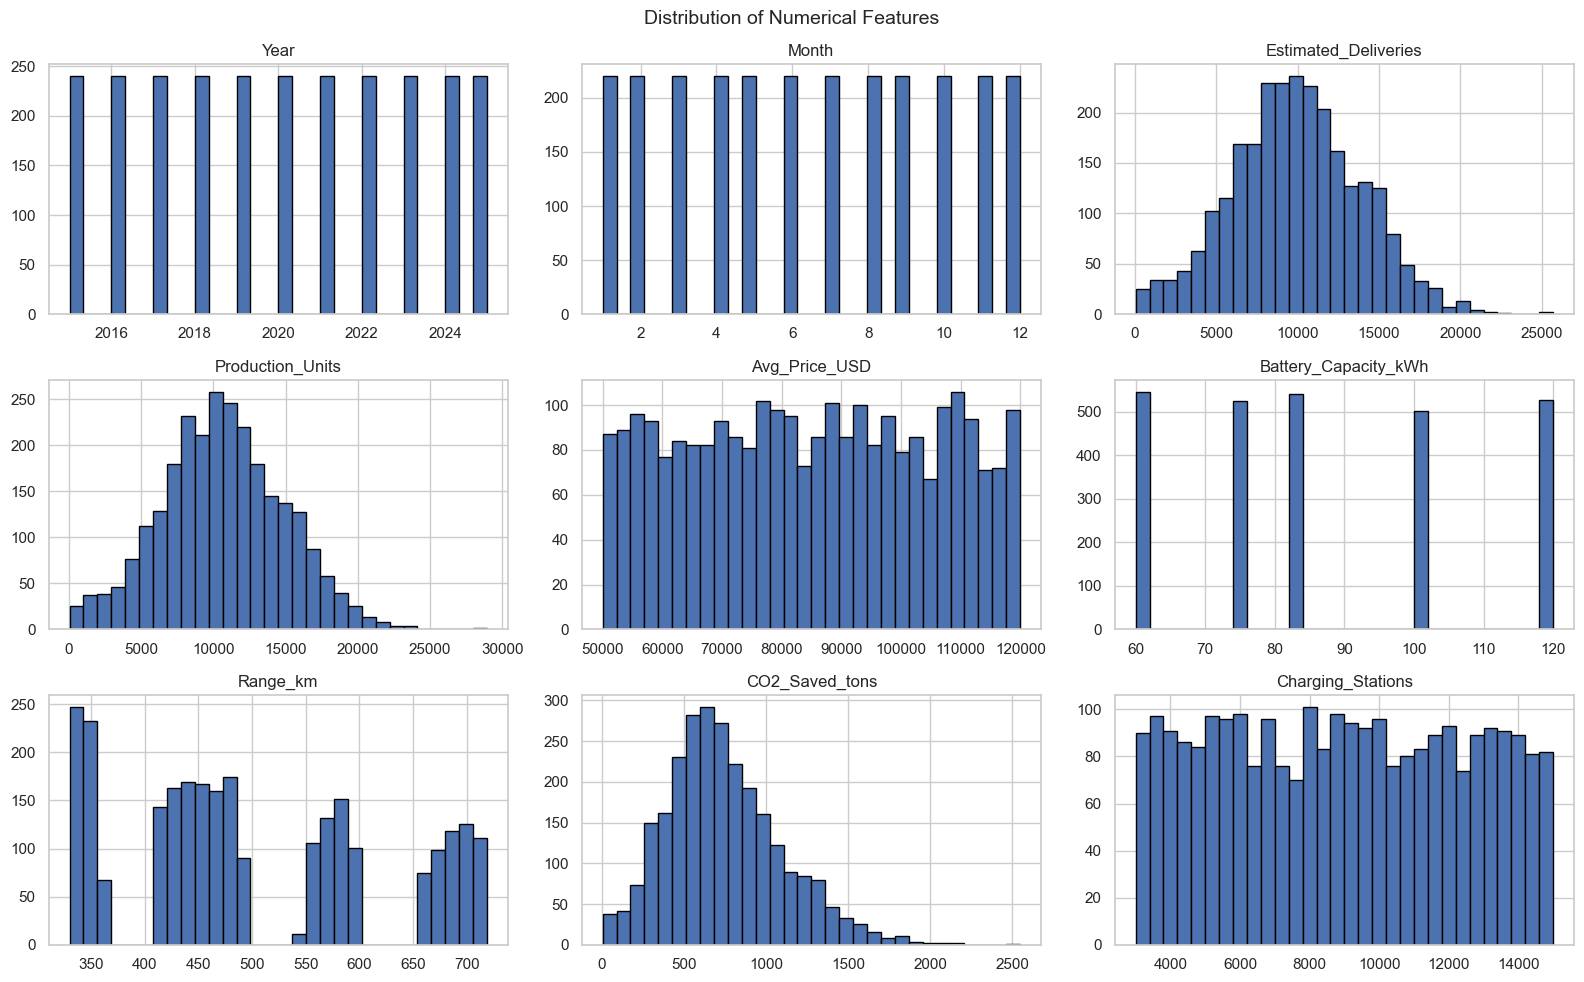

In [7]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df[numerical_cols].hist(bins=30, figsize=(16, 10), edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### 2b. Bivariate Analysis

checking how estimated deliveries relate to year, region, and model

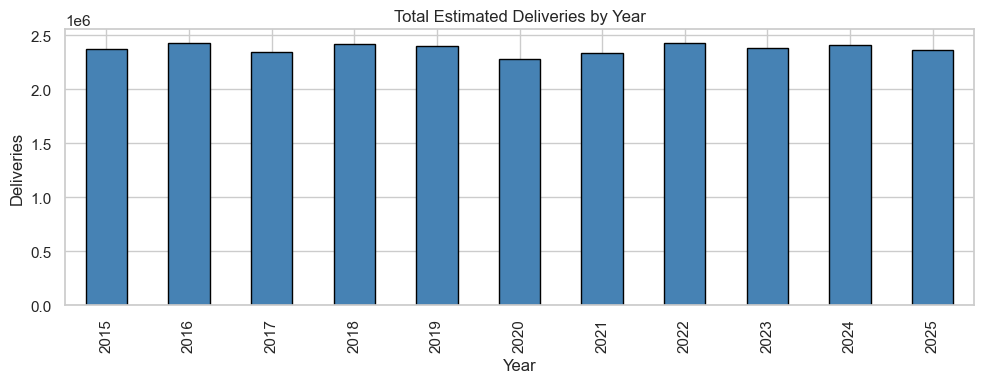

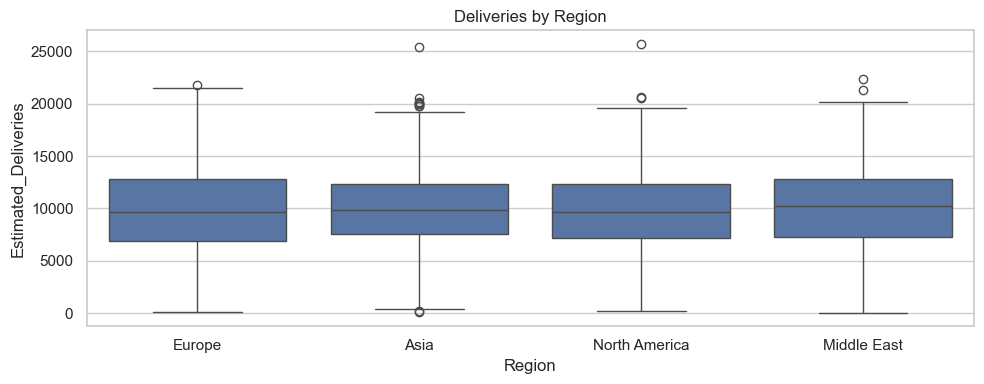

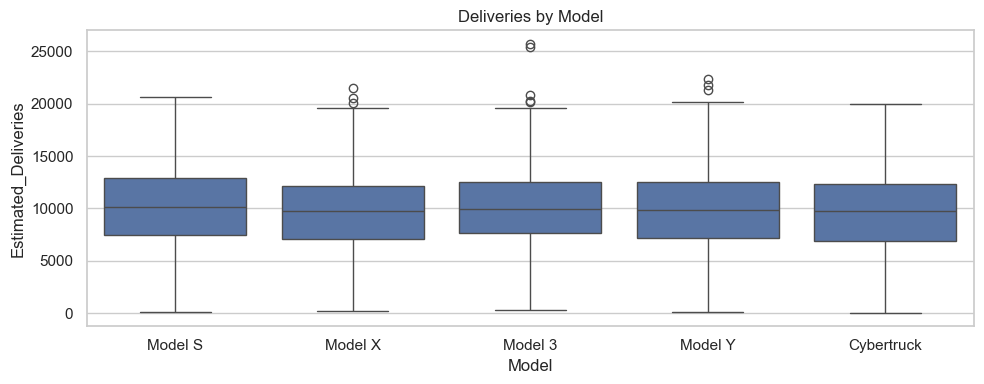

In [8]:
# deliveries trend over years
plt.figure(figsize=(10, 4))
df.groupby('Year')['Estimated_Deliveries'].sum().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Estimated Deliveries by Year')
plt.ylabel('Deliveries')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

# deliveries by region
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Region', y='Estimated_Deliveries')
plt.title('Deliveries by Region')
plt.tight_layout()
plt.show()

# deliveries by model
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Model', y='Estimated_Deliveries')
plt.title('Deliveries by Model')
plt.tight_layout()
plt.show()

### Observation

All three plots show a surprisingly uniform distribution across years, regions, and models which is unusual for real world data. In reality Tesla deliveries grew significantly over the years and certain models like Model 3 and Model Y dominate sales. This uniformity suggests the dataset is synthetically generated for learning purposes and not real world data.

### 2c. Correlation Heatmap

showing how numerical features are correlated with each other — useful to spot which features are most related to our target

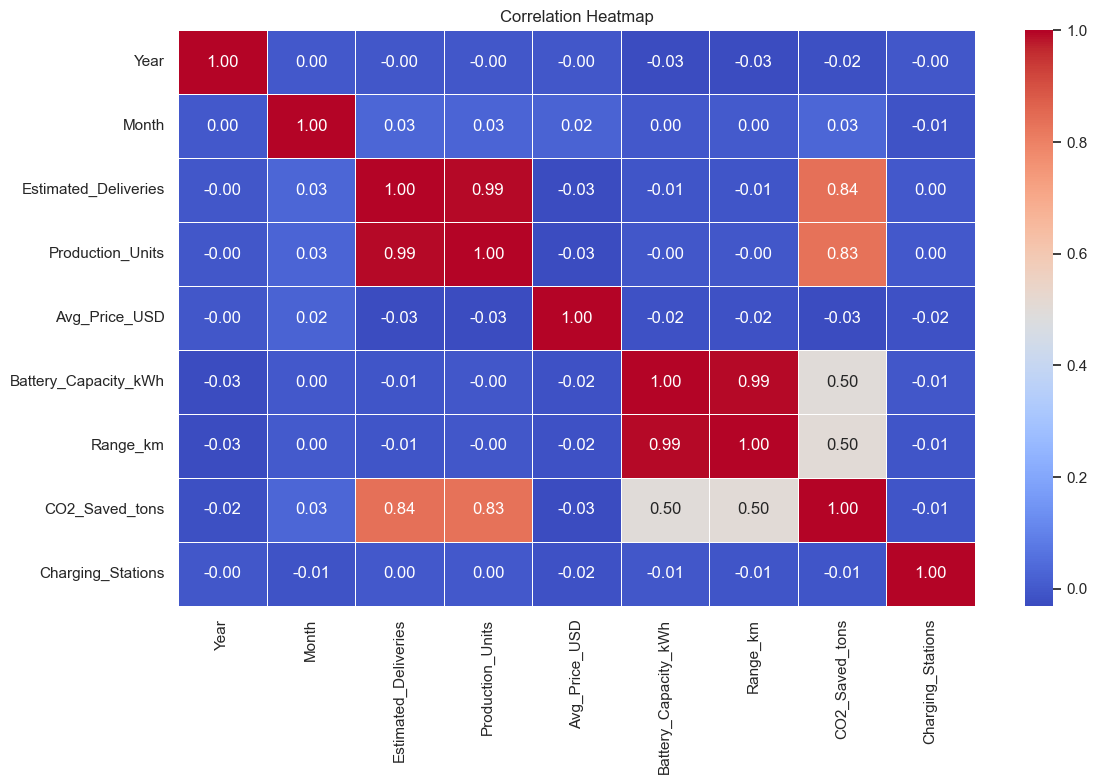

In [9]:
plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 3. Encoding Categorical Variables

We encode our categorical variables (Region, Model, Source_Type) using OneHotEncoder.

In [10]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(drop='first', sparse_output=False)
cat_cols = ['Region', 'Model', 'Source_Type']
encoded_array = encoder.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(cat_cols))

# Combine with numerical columns
numerical_cols = df.select_dtypes(include=['number'])
df_encoded = pd.concat([numerical_cols, encoded_df], axis=1)
df_encoded.head()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 4. Feature Engineering

Creating a 'quarter' feature from the 'Month' column.

In [11]:
# create quarter from Month
df_encoded['quarter'] = df_encoded['Month'].apply(lambda x: (x - 1) // 3 + 1)

# dropping any remaining non-numeric columns just to be safe
df_encoded = df_encoded.select_dtypes(include=['number'])
df_encoded.head()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter),quarter
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4


## 5. Train-Test Split and Scaling

Splitting data into 80% train and 20% test, and then scaling features.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('Estimated_Deliveries', axis=1)
y = df_encoded['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6. Baseline — Linear Regression

Training a baseline Linear Regression model and evaluating its performance.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Metrics:")
print(f"RMSE: {lr_rmse:.2f}")
print(f"MAE: {lr_mae:.2f}")
print(f"MSE: {lr_mse:.2f}")
print(f"R2: {lr_r2:.4f}")


Linear Regression Metrics:
RMSE: 383.93
MAE: 309.56
MSE: 147402.51
R2: 0.9901


## 7. Ridge Regression

Tuning hyperparameter alpha for Ridge Regression using K-Fold cross validation.

In [14]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

alphas = [0.01, 0.1, 1, 10, 100]
best_alpha_ridge = None
best_rmse_ridge = float('inf')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for alpha in alphas:
    model = Ridge(alpha=alpha)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    if rmse < best_rmse_ridge:
        best_rmse_ridge = rmse
        best_alpha_ridge = alpha

print(f"Best alpha for Ridge: {best_alpha_ridge}")

ridge_model = Ridge(alpha=best_alpha_ridge)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)


Best alpha for Ridge: 0.1


## 8. Lasso Regression

Tuning hyperparameter alpha for Lasso Regression using K-Fold cross validation.

In [15]:
from sklearn.linear_model import Lasso

best_alpha_lasso = None
best_rmse_lasso = float('inf')

for alpha in alphas:
    model = Lasso(alpha=alpha)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    if rmse < best_rmse_lasso:
        best_rmse_lasso = rmse
        best_alpha_lasso = alpha

print(f"Best alpha for Lasso: {best_alpha_lasso}")

lasso_model = Lasso(alpha=best_alpha_lasso)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)


Best alpha for Lasso: 10


## 9. Model Comparison

Comparing our three regression models side by side.

In [16]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse],
    'MAE': [lr_mae, ridge_mae, lasso_mae],
    'MSE': [lr_mse, ridge_mse, lasso_mse],
    'R2 Score': [lr_r2, ridge_r2, lasso_r2]
})

results


,Model,RMSE,MAE,MSE,R2 Score
0,Linear Regression,383.930339,309.560939,147402.505111,0.990111
1,Ridge Regression,383.932072,309.539508,147403.836173,0.990111
2,Lasso Regression,382.393847,309.922552,146225.054516,0.990190


## 10. Time Series Forecasting

Aggregating the dataset to form a monthly time series for forecasting.

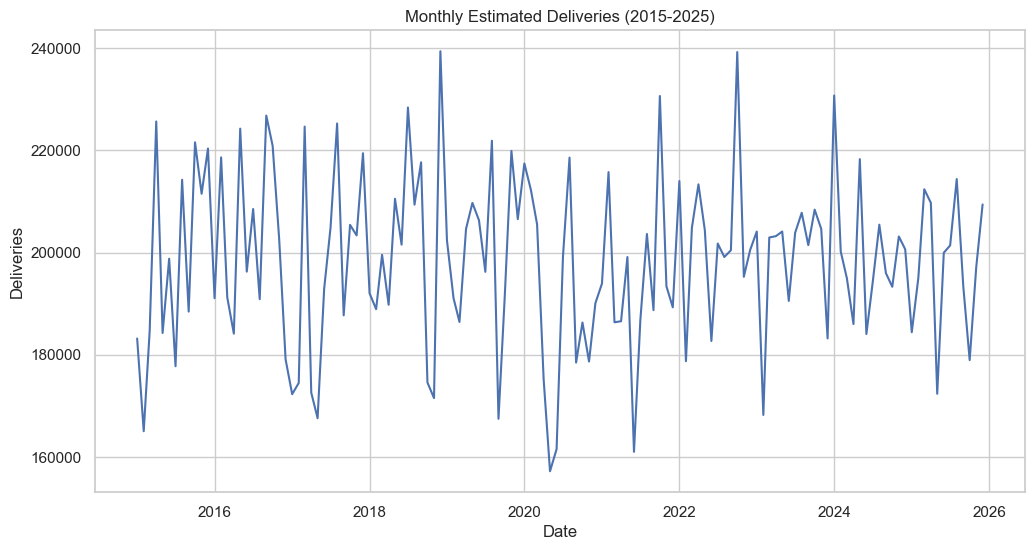

In [17]:
# aggregate by Year and Month
ts_df = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()

# create a datetime index
ts_df['Date'] = pd.to_datetime(ts_df['Year'].astype(str) + '-' + ts_df['Month'].astype(str) + '-01')
ts_df.set_index('Date', inplace=True)
ts_series = ts_df['Estimated_Deliveries']

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(ts_series)
plt.title('Monthly Estimated Deliveries (2015-2025)')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.show()


Decomposing the time series into trend, seasonal, and residual components.

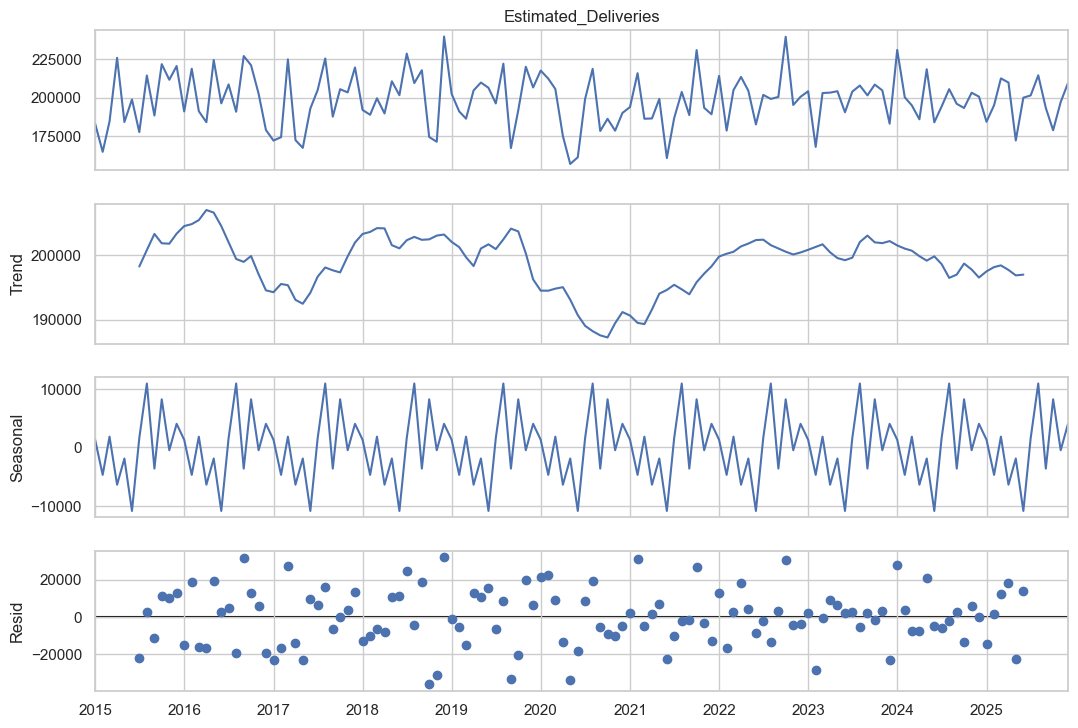

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts_series, period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()


Running the Augmented Dickey-Fuller test to check for stationarity.

In [19]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(ts_series)
print('ADF Statistic:', adf_test[0])
print('p-value:', adf_test[1])


ADF Statistic: -8.880990349502863
p-value: 1.3181396968154108e-14


Creating lag features and a rolling mean.

In [20]:
ts_features = ts_df[['Estimated_Deliveries']].copy()
ts_features['lag_1'] = ts_features['Estimated_Deliveries'].shift(1)
ts_features['lag_2'] = ts_features['Estimated_Deliveries'].shift(2)
ts_features['lag_3'] = ts_features['Estimated_Deliveries'].shift(3)
ts_features['rolling_mean_3'] = ts_features['Estimated_Deliveries'].rolling(window=3).mean()

ts_features.head()


,Estimated_Deliveries,lag_1,lag_2,lag_3,rolling_mean_3
Date,,,,,
2015-01-01,183180,NaN,NaN,NaN,NaN
2015-02-01,165053,183180.0,NaN,NaN,NaN
2015-03-01,184567,165053.0,183180.0,NaN,177600.000000
2015-04-01,225623,184567.0,165053.0,183180.0,191747.666667
2015-05-01,184264,225623.0,184567.0,165053.0,198151.333333


Splitting the data chronologically and fitting an ARIMA model.

c:\Users\khush\ML_DS_VS\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\khush\ML_DS_VS\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\khush\ML_DS_VS\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


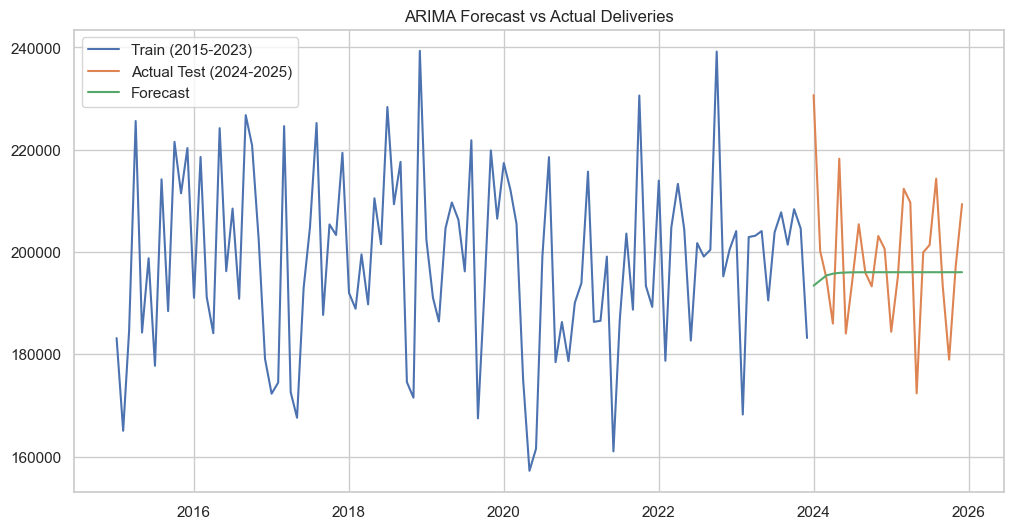

ARIMA RMSE: 13439.11
ARIMA MAE: 10049.54


In [21]:
from statsmodels.tsa.arima.model import ARIMA

train_ts = ts_series['2015':'2023']
test_ts = ts_series['2024':'2025']

arima_model = ARIMA(train_ts, order=(2, 1, 2))
arima_result = arima_model.fit()

forecast = arima_result.forecast(steps=len(test_ts))

plt.figure(figsize=(12, 6))
plt.plot(train_ts.index, train_ts, label='Train (2015-2023)')
plt.plot(test_ts.index, test_ts, label='Actual Test (2024-2025)')
plt.plot(test_ts.index, forecast, label='Forecast')
plt.title('ARIMA Forecast vs Actual Deliveries')
plt.legend()
plt.show()

arima_rmse = np.sqrt(mean_squared_error(test_ts, forecast))
arima_mae = mean_absolute_error(test_ts, forecast)

print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"ARIMA MAE: {arima_mae:.2f}")
